# 机器学习笔记：从建模流程到可解释评估

这份 notebook 用于整理机器学习的核心复习框架，并给出可以直接运行的 Python 示例。目标不是堆模型名称，而是形成一套清晰的建模思路：明确问题、理解数据、建立基线、评估泛化能力、解释模型结果。


## 1. 标准建模流程

一个完整的机器学习任务通常包括：

1. 明确任务类型：分类、回归、聚类、排序或时间序列预测。
2. 数据理解：变量含义、缺失值、异常值、样本量、类别不平衡。
3. 特征工程：数值标准化、类别编码、文本向量化、交互项构造。
4. 建立基线模型：先用简单模型得到可比较的起点。
5. 模型训练与调参：使用交叉验证减少偶然性。
6. 模型评估：关注训练集和测试集差距，判断过拟合或欠拟合。
7. 结果解释：用特征重要性、系数、误差分析解释模型行为。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

np.random.seed(42)


## 2. 示例任务：二分类预测

下面使用 `breast_cancer` 数据集演示监督学习中的二分类流程。实际项目中，应优先把业务问题翻译为可评估的预测目标，再选择模型。

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.shape)
display(X.head())
print(y.value_counts(normalize=True).rename("class_ratio"))


(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
1    0.627417
0    0.372583
Name: class_ratio, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)
prob = baseline.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "auc": roc_auc_score(y_test, prob)
}

pd.Series(metrics).round(4)


accuracy     0.9860
precision    0.9889
recall       0.9889
f1           0.9889
auc          0.9977
dtype: float64

## 3. 为什么不只看准确率

准确率适合类别相对均衡、错误成本接近的场景。若正负样本不平衡，或漏判/误判成本不同，应同时关注 precision、recall、F1、AUC 和混淆矩阵。

- Precision：预测为正的样本中，有多少是真的正样本。
- Recall：真实正样本中，有多少被模型找出来。
- F1：precision 和 recall 的调和平均。
- AUC：模型整体排序能力，和具体阈值关系较弱。


In [4]:
cm = confusion_matrix(y_test, pred)
cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
cm_df


,pred_0,pred_1
true_0,52,1
true_1,1,89


## 4. 交叉验证：减少一次划分带来的偶然性

单次训练集/测试集划分可能受到样本分布影响。交叉验证通过多次划分训练和验证模型，更适合用于模型选择和超参数比较。

In [5]:
cv_scores = cross_val_score(baseline, X, y, cv=5, scoring="roc_auc")
print("AUC scores:", np.round(cv_scores, 4))
print("mean AUC:", round(cv_scores.mean(), 4))
print("std:", round(cv_scores.std(), 4))


AUC scores: [0.9948 0.9967 0.997  0.9878 0.9997]
mean AUC: 0.9952
std: 0.004


## 5. 模型对比：线性模型 vs 随机森林

线性模型通常更容易解释，随机森林能捕捉非线性关系。求职项目中，建议既展示模型效果，也说明为什么选择某个模型。

In [6]:
models = {
    "Logistic Regression": baseline,
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    rows.append({"model": name, "mean_auc": scores.mean(), "std_auc": scores.std()})

pd.DataFrame(rows).round(4)


,model,mean_auc,std_auc
0,Logistic Regression,0.9952,0.0040
1,Random Forest,0.9921,0.0057


## 6. 特征重要性与解释

模型解释要回答两个问题：

1. 哪些变量对预测最有贡献？
2. 这些贡献是否符合专业知识或业务直觉？

下面用随机森林的特征重要性做一个快速示例。

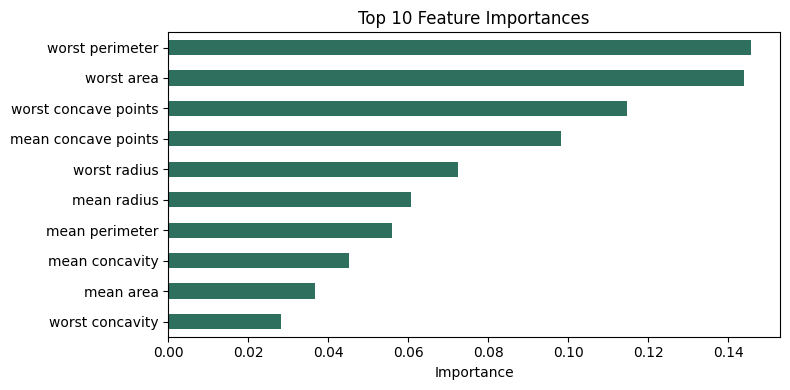

In [ ]:
forest = RandomForestClassifier(n_estimators=300, random_state=42)
forest.fit(X_train, y_train)

importance = pd.Series(forest.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

ax = importance.sort_values().plot(kind="barh", figsize=(8, 4), color="#2e6f5e")
ax.set_title("Top 10 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 7. 面试表达模板

介绍一个机器学习项目时，可以按以下顺序表达：

- 问题：我需要预测什么，为什么这个目标重要？
- 数据：数据来源、样本量、主要字段、清洗难点。
- 方法：建立了什么基线，尝试了哪些模型，如何调参。
- 评估：选择哪些指标，为什么这些指标适合该任务。
- 解释：关键特征是什么，是否符合业务或专业判断。
- 结果：模型带来了什么结论、建议或可部署价值。
